# Technische Universität Clausthal - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS fak_name,
                        'Technische Universität Clausthal' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/04qb8nc58' -- 'Technische Universität Clausthal'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Technische Universität Clausthal,"Clausthal University of Technology, Institute ...",https://openalex.org/W4293051704
1,not assigned,Technische Universität Clausthal,Clausthal University of Technology Institute f...,https://openalex.org/W4293051704
2,not assigned,Technische Universität Clausthal,Institute of Tribology and Energy Conversion M...,https://openalex.org/W4285594857
3,not assigned,Technische Universität Clausthal,"Institut für Mathematik, TU Clausthal, Clausth...",https://openalex.org/W4206993102
4,not assigned,Technische Universität Clausthal,"Institute of Mineral and Waste Processing, Rec...",https://openalex.org/W4283735955


In [6]:
MAPPING_DICT = {
    'Clausthaler Umwelttechnik Forschungszentrum (CUTEC)': ['cutec'],
    'Clausthaler Zentrum für Materialtechnik (CZM)': ['(czm)', 'cent(er|re) (for|of) material(s)? technology', 'zentrum für materialtech(nik|nologie)',
                                                     ],
    'Fakultät für Energie- und Wirtschaftswissenschaften': ['mineral', 'geo(-engineering|mechanic)', 'market', 'fuel technology',
                                                            '(sub)?surface energy', 'power engineering', 'geolog(ie|y)', 'economics',
                                                            'thermodynamic', 'verfahrenstechnik', 'betriebswirtschaftslehre',
                                                            'mining', 'geophysi(k|cs)', '(energie|deponie)technik', 'petroleum', 'faculty for energy',
                                                            'economics', 'endlagerforschung', '(geotechnical|energy) engineering',
                                                            'kreislaufwirtschaftssysteme', 'repository', 'electric(al)? power',
                                                            'circular economy', 'digital transformation', 'disposal'
                                                           ], 
    'Fakultät für Mathematik/Informatik und Maschinenbau': ['software (and system|systems engineering)', 'tribology', 
                                                            'chemical', 'mathemati(cs|k|cal)',
                                                            'informati(k|cs)', 'particle',
                                                            'welding', 'stochastics', 'anlagentechnik',
                                                            'computer science', '(applied|technical) mechanics',
                                                            'data science', 'continuous optimization',
                                                            'maschinenwesen', 'informationstechnik',
                                                            '(hcis)', 'separation', 'human(-|\s)centered', 
                                                            'electrical information', '(mechanical|plant) engineering',
                                                            'schweißtechnik', 'mechanical', 'isse,', 'isaf,'
                                                           ],
    'Fakultät für Natur- und Materialwissenschaften': ['materials (science|engineering)', 'chemi(e|stry)', 'non(‐|-)?metallic', 
                                                       'metallurg(ie|y)', 'physical technologies', 'nichtmetallische',
                                                       'theoreti(sche|cal) physi(k|cs)', 'werkstoff(kunde|technik)',
                                                       'polymer', 'energieforschung', 'energy research cent(er|re)'
                                                      ],
    'Forschungszentrum Energiespeichertechnologien': ['energy storage', 'energiespeichertechnologien'],
    #'Geomuseum': [],
    #'LaserAnwendungsCentrum': []
}

In [7]:
with open('./mapping_tables_fak/clausthal.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [8]:
df_with_inst = oal.copy()

In [9]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [10]:
df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [11]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,Fakultät für Mathematik/Informatik und Maschin...,Technische Universität Clausthal,"Clausthal University of Technology, Institute ...",https://openalex.org/W4293051704
1,Fakultät für Mathematik/Informatik und Maschin...,Technische Universität Clausthal,Clausthal University of Technology Institute f...,https://openalex.org/W4293051704
2,Fakultät für Mathematik/Informatik und Maschin...,Technische Universität Clausthal,Institute of Tribology and Energy Conversion M...,https://openalex.org/W4285594857
3,Fakultät für Mathematik/Informatik und Maschin...,Technische Universität Clausthal,"Institut für Mathematik, TU Clausthal, Clausth...",https://openalex.org/W4206993102
4,Fakultät für Energie- und Wirtschaftswissensch...,Technische Universität Clausthal,"Institute of Mineral and Waste Processing, Rec...",https://openalex.org/W4283735955
...,...,...,...,...
3134,None,Technische Universität Clausthal,TU Clausthal,https://openalex.org/W3022257217
3135,None,Technische Universität Clausthal,TU Clausthal,https://openalex.org/W4401024531
3136,None,Technische Universität Clausthal,TU Clausthal,https://openalex.org/W4414359516
3137,None,Technische Universität Clausthal,TU Clausthal,https://openalex.org/W3215011279


In [12]:
df_with_inst[df_with_inst.fak_name.isnull()].raw_affiliation_string.unique()

array(['Clausthal University of Technology,Clausthal-Zellerfeld,Germany,38678',
       'Clausthal University of Technology, Clausthal-Zellerfeld, Lower Saxony, Germany',
       'Scientific Computing, Technical University of Clausthal, Clausthal, Germany',
       'TU Clausthal, Clausthal, Germany',
       'Technische Univ. Clausthal (Germany)',
       'Technical University of Clausthal',
       'IEPT, Clausthal University of Technology, Am Stollen 19A, 38678 Clausthal-Zellerfeld, Germany',
       'Technische Universität Clausthal',
       'Technische Universität Clausthal, 38678, Clausthal-Zellerfeld, Germany',
       'TU Clausthal - Clausthal University of Technology (Adolph-Roemer-Straße 2A\r\nD-38678 - Germany)',
       'TU Clausthal, Germany',
       'Clausthal University of Technology, Clausthal-zellerfeld, 38678, Germany',
       'TU Clausthal,Germany',
       'Clausthal University of Technology, Clausthal, Germany',
       'Clausthal University of Technology,Clausthal,Germany',
 

In [13]:
df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()

,fak_name,openalex_id
0,Clausthaler Umwelttechnik Forschungszentrum (C...,25
1,Clausthaler Zentrum für Materialtechnik (CZM),107
2,Fakultät für Energie- und Wirtschaftswissensch...,635
3,Fakultät für Mathematik/Informatik und Maschin...,895
4,Fakultät für Natur- und Materialwissenschaften,857
5,Forschungszentrum Energiespeichertechnologien,92
6,NaN,528


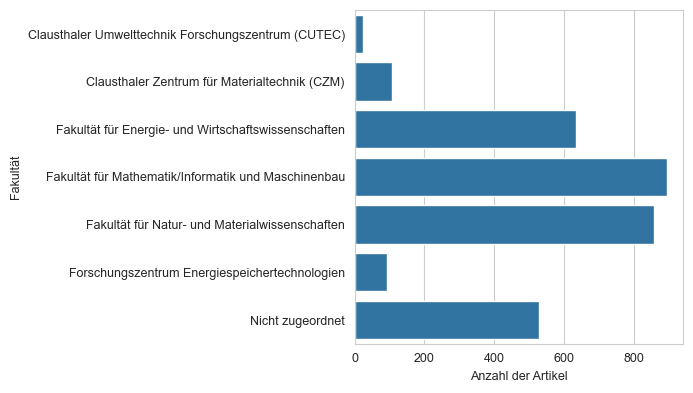

In [14]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [15]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.8317935648295636

In [298]:
MAPPING_DICT_DEPT = {
    'Fakultät für Energie- und Wirtschaftswissenschaften': {
        'Institut für Aufbereitung, Deponietechnik und Geomechanik (IFAD)': ['deponietechnik', 'disposal research'],
        'Institut für Aufbereitung, Recycling und Kreislaufwirtschaftssysteme': ['waste processing', 'kreislaufwirtschaftssysteme', 'circular economy'
                                                                                ],
        'Institut für Bergbau': ['(surface|international) mining', 'institute of mining', 'mining engineering'],
        #'Institut für deutsches und internationales Berg- und Energierecht': [],
        'Institut für Elektrische Energietechnik und Energiesysteme': ['elektrische energietechnik', 'electrical(\spower)? engineering'],
        'Institut für Endlagerforschung': ['mineral resources', 'chair for geomechanics', 'endlagerforschung'],
        'Institut für Energieverfahrenstechnik und Brennstofftechnik': ['fuel technology', 'verfahrenstechnik', 'thermodynamics'],
        'Institut für Erdöl- und Erdgastechnik': ['petroleum engineering'],
        'Institut für Geologie und Paläontologie': ['paläontologie', 'pal(a)?eontology'],
        'Institut für Geophysik': ['institute of geophysics', 'institut f(ü|u)r geophysik'],
        'Institut für Wirtschaftswissenschaft': ['(behavioral|environmental) (economics|management)', 'management and economics', 
                                                 '(department|institute) of economics', 
                                                 'marketing', 'betriebswirtschaftslehre',
                                                 'digital transformation', 'market research', 'energy and economics'
                                                ],
        'Institute of Geotechnology and Mineral Resources': ['repository (research|systems)', 'geo-engineering', 'geotechnical engineering'],
        'Institute of Subsurface Energy Systems': ['surface energy']
    },
    'Fakultät für Mathematik/Informatik und Maschinenbau': {
        'Institut für Chemische und Elektrochemische Verfahrenstechnik': ['chemical'],
        'Institut für Elektrische Informationstechnik': ['electrical information technology', 'elektrische informationstechnik'],
        'Institut für Informatik': ['(dep(t.|artment)|institute) (of|for) informatics', 'ins(t)?itut \S+ informatik', 'computer science', 'energy informatics'
                                   ],
        'Institut für Maschinelle Anlagentechnik und Betriebsfestigkeit': ['plant engineering', 'maschinelle anlagentechnik'],
        'Institut für Maschinenwesen': ['maschinenwesen', 'mechanical engineering'],
        'Institut für Mathematik': ['(dep(t.|artment)|institute) (of|for) mathematics', 'ins(t)?itut f(ü|u)?r mathematik', 'angewandte (stochastik|statistik)', 
                                    'applied (stochastics|statistics)', 'mathematical institute', 'continuous optimization'
                                   ],
        'Institut für Mechanische Verfahrenstechnik': ['particle technology'],
        'Institut für Prozeß- und Produktionsleittechnik': ['process technology', 'mechanical process'],
        'Institut für Schweißtechnik und Trennende Fertigungsverfahren': ['welding and (machining|cutting)', 'schweißtechnik', 'isaf,'],
        'Institut für Software and Systems Engineering': ['system(s)? engineering', 'human(-|\s)?centered information systems', 'isse,', 'software and systems'],
        'Institut für Technische Mechanik': ['applied mechanics', 'technical mechanics'],
        'Institut für Thermische Verfahrens- und Prozesstechnik': ['thermische verfahren'],
        'Institut für Tribologie und Energiewandlungsmaschinen': ['tribolog(ie|y)'],
    },
    'Fakultät für Natur- und Materialwissenschaften': {
        'Institut für Anorganische und Analytische Chemie': ['analytic(al)? chemistry', 'analytische chemie'],
        'Institut für Elektrochemie': ['electrochemistry', 'elektrochemie'],
        'Institut für Energieforschung und Physikalische Technologien': ['energy research', 'physikalische technologien'],
        'Institut für Metallurgie': ['metallurgy', 'metallurgie'],
        'Institut für Nichtmetallische Werkstoffe': ['non(-|‐)?metallic', 'nichtmetallische'],
        'Institut für Organische Chemie': ['organic(\s\S+)? chemistry', 'institut für organische chemie'],
        'Institut für Physikalische Chemie': ['physical chemistry', 'physikalische chemie'],
        'Institut für Polymerwerkstoffe und Kunststofftechnik': ['polymer materials', 'polymerwerkstoffe'],
        'Institut für Technische Chemie': ['technical chemistry', 'technische chemie'],
        'Institut für Theoretische Physik': ['theoretical physics', 'theoretische physik'],
        'Institut für Werkstoffkunde und Werkstofftechnik': ['materials science', 'werkstoff(technik|kunde)', 'materials engineering'],
    }
}

In [299]:
with open('./mapping_tables_dept/clausthal.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_DEPT, f, ensure_ascii=False)

In [300]:
def map_dept(address: str, faculty: str) -> Union[str, None]:
    if faculty in MAPPING_DICT_DEPT:
        for k, v in MAPPING_DICT_DEPT.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [301]:
df_with_inst.loc[df_with_inst['fak_name'] == 'Fakultät für Natur- und Materialwissenschaften', 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == 'Fakultät für Natur- und Materialwissenschaften']['raw_affiliation_string'].apply(map_dept, 
                                                                                                    faculty='Fakultät für Natur- und Materialwissenschaften')

In [302]:
df_with_inst[(df_with_inst['fak_name'] == 'Fakultät für Natur- und Materialwissenschaften') & df_with_inst['dept_name'].isnull()].raw_affiliation_string.unique()[:20]

array(['Institute of Chemistry, University of Technology Clausthal, Leibnizstraße 4a, 38678, Clausthal-Zellerfeld, Germany'],
      dtype=object)

In [303]:
df_with_inst[df_with_inst['fak_name'] == 'Fakultät für Natur- und Materialwissenschaften'].groupby(['dept_name'], dropna=False)['openalex_id'].count().reset_index()

,dept_name,openalex_id
0,Institut für Anorganische und Analytische Chemie,52
1,Institut für Elektrochemie,55
2,Institut für Energieforschung und Physikalisch...,104
3,Institut für Metallurgie,174
4,Institut für Nichtmetallische Werkstoffe,98
5,Institut für Organische Chemie,117
6,Institut für Physikalische Chemie,53
7,Institut für Polymerwerkstoffe und Kunststofft...,77
8,Institut für Technische Chemie,56
9,Institut für Theoretische Physik,12


In [304]:
df_with_inst[df_with_inst['fak_name'] == 'Fakultät für Natur- und Materialwissenschaften']

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name
6,Fakultät für Natur- und Materialwissenschaften,Technische Universität Clausthal,Institute of Polymer Materials and Plastics En...,https://openalex.org/W4223984616,Institut für Polymerwerkstoffe und Kunststofft...
7,Fakultät für Natur- und Materialwissenschaften,Technische Universität Clausthal,"Institute of Metallurgy, Clausthal University ...",https://openalex.org/W4399550695,Institut für Metallurgie
9,Fakultät für Natur- und Materialwissenschaften,Technische Universität Clausthal,"Institute of Metallurgy, Clausthal University ...",https://openalex.org/W4294564676,Institut für Metallurgie
16,Fakultät für Natur- und Materialwissenschaften,Technische Universität Clausthal,"Institute of Metallurgy (IMET), Clausthal Univ...",https://openalex.org/W4224932937,Institut für Metallurgie
22,Fakultät für Natur- und Materialwissenschaften,Technische Universität Clausthal,Institute of Non-Metallic Materials [Clausthal...,https://openalex.org/W4304759549,Institut für Nichtmetallische Werkstoffe
...,...,...,...,...,...
3094,Fakultät für Natur- und Materialwissenschaften,Technische Universität Clausthal,"Institute of Non-Metallic Materials, Clausthal...",https://openalex.org/W3175507923,Institut für Nichtmetallische Werkstoffe
3095,Fakultät für Natur- und Materialwissenschaften,Technische Universität Clausthal,"Institute of Non-Metallic Materials, Clausthal...",https://openalex.org/W3046910561,Institut für Nichtmetallische Werkstoffe
3096,Fakultät für Natur- und Materialwissenschaften,Technische Universität Clausthal,"Institute of Non-Metallic Materials, Clausthal...",https://openalex.org/W3099772648,Institut für Nichtmetallische Werkstoffe
3097,Fakultät für Natur- und Materialwissenschaften,Technische Universität Clausthal,"Institute of Non-Metallic Materials, Clausthal...",https://openalex.org/W3144335920,Institut für Nichtmetallische Werkstoffe
